In [2]:
import os
import pandas as pd

In [3]:
BASE = os.path.join(os.getcwd(), "..")  # project root

orders   = pd.read_csv(os.path.join(BASE, "Data", "raw", "orders.csv"))

In [5]:
#checking duplicates
dup_count = int(orders.duplicated(subset="order_id").sum())
#checking nulls
missing_val = orders.isna().sum()
#Number of sellers
total_seller = orders["order_id"].nunique()

#checking the consistency of category and subcategory

uni_payment = list(orders["payment_method"].unique())
uni_status = list(orders["payment_method"].unique())


#checking dtype
orders.dtypes


order_id                      str
customer_id                   str
created_at                    str
status                        str
payment_method                str
promised_delivery_date        str
is_fast_delivery_eligible    bool
dtype: object

In [25]:
orders["created_at"] = pd.to_datetime(orders["created_at"])
orders["promised_delivery_date"] = pd.to_datetime(orders["promised_delivery_date"])

In [26]:
orders.dtypes


order_id                                str
customer_id                             str
created_at                   datetime64[us]
status                                  str
payment_method                          str
promised_delivery_date       datetime64[us]
is_fast_delivery_eligible              bool
dtype: object

In [12]:
total_orders = orders["order_id"].nunique()

In [13]:
print(f"""
========================================
        ORDERS TABLE SUMMARY
========================================
  Total Orders               : {total_orders}
  number of payment method   : {len(uni_payment)}
  number of delivary status  : {len(uni_payment)}
  Duplicates                 : {dup_count}
  Missing Values             : {missing_val.any()}
========================================
""")


        ORDERS TABLE SUMMARY
  Total Orders               : 100000
  number of payment method   : 5
  number of delivary status  : 5
  Duplicates                 : 0
  Missing Values             : False



In [33]:
orders["order_year"] = orders["created_at"].dt.year
orders["order_monthname"] = orders["created_at"].dt.month_name()
orders["order_month"] = orders["created_at"].dt.month



In [51]:
orders.columns

Index(['order_id', 'customer_id', 'created_at', 'status', 'payment_method',
       'promised_delivery_date', 'is_fast_delivery_eligible', 'order_year',
       'order_month', 'order_monthname'],
      dtype='str')

In [52]:
val = (orders.groupby(["order_year", "order_month", "order_monthname"])["order_id"]
       .count()
       .reset_index()
       .sort_values(["order_year", "order_month"])
       .pivot(index="order_year", columns="order_monthname", values="order_id"))

# Reorder columns Jan to Dec
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

val = val.reindex(columns =[m for m in month_order if m in val.columns])

# Add totals
val["Total"] = val.sum(axis=1)
val.loc["Total"] = val.sum()


In [84]:
#val

In [55]:
# H2 months
h2_months = ["July", "August", "September", "October", "November", "December"]

# Filter H2 orders for 2024 and 2025
h2_comparison = (orders[orders["order_monthname"].isin(h2_months)]
                 .groupby("order_year")["order_id"]
                 .count()
                 .reset_index())

h2_comparison.columns = ["order_year", "h2_orders"]

# YoY Growth
h2_2024 = h2_comparison.loc[h2_comparison["order_year"] == 2024, "h2_orders"].values[0]
h2_2025 = h2_comparison.loc[h2_comparison["order_year"] == 2025, "h2_orders"].values[0]

yoy_growth = ((h2_2025 - h2_2024) / h2_2024 * 100).round(2)

print("H2 (Jul-Dec) YoY Comparison")
print(h2_comparison)
print(f"\n2024 H2 Orders : {h2_2024:,}")
print(f"2025 H2 Orders : {h2_2025:,}")
print(f"YoY Growth     : {yoy_growth}%")

H2 (Jul-Dec) YoY Comparison
   order_year  h2_orders
0        2024      33794
1        2025      33298

2024 H2 Orders : 33,794
2025 H2 Orders : 33,298
YoY Growth     : -1.47%


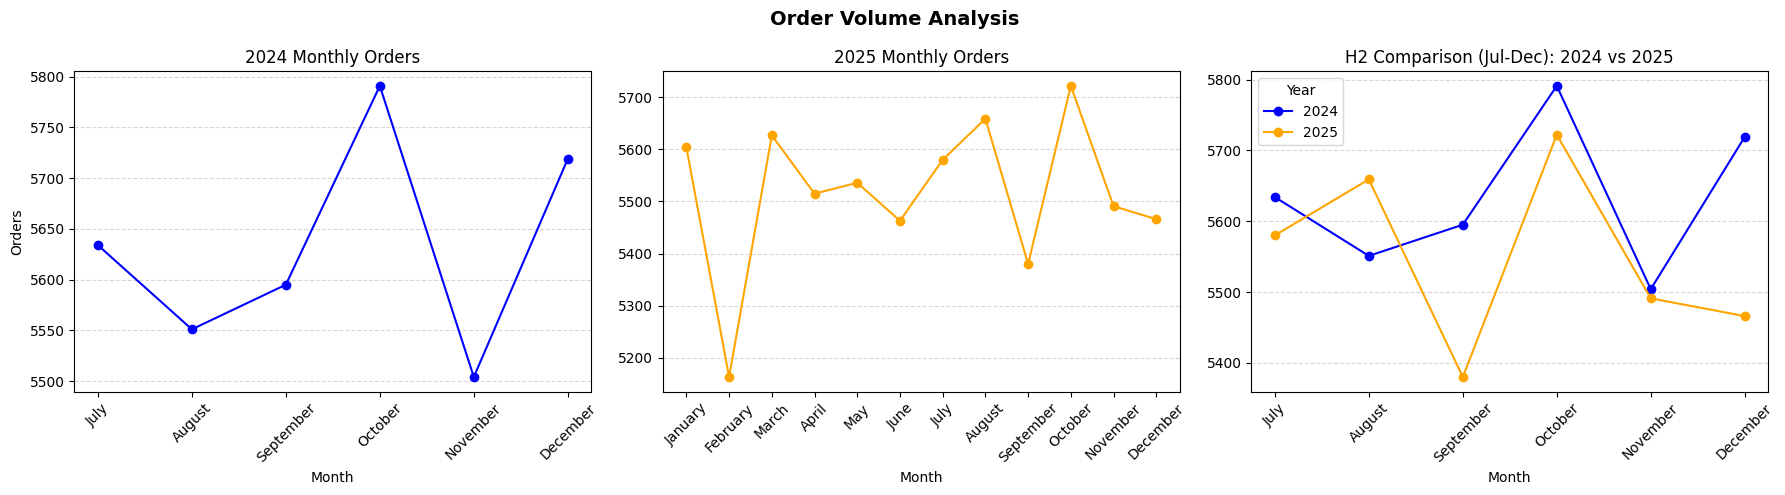

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Separate data by year
data_2024 = plot_data[plot_data["order_year"] == 2024].sort_values("order_month")
data_2025 = plot_data[plot_data["order_year"] == 2025].sort_values("order_month")

# Plot 1 - 2024
axes[0].plot(data_2024["order_monthname"], data_2024["order_id"], marker="o", color="blue")
axes[0].set_title("2024 Monthly Orders")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Orders")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Plot 2 - 2025
axes[1].plot(data_2025["order_monthname"], data_2025["order_id"], marker="o", color="orange")
axes[1].set_title("2025 Monthly Orders")
axes[1].set_xlabel("Month")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# Plot 3 - Comparison (H2 only - common months)
h2_months = ["July", "August", "September", "October", "November", "December"]
h2_2024 = data_2024[data_2024["order_monthname"].isin(h2_months)]
h2_2025 = data_2025[data_2025["order_monthname"].isin(h2_months)]

axes[2].plot(h2_2024["order_monthname"], h2_2024["order_id"], marker="o", color="blue",  label="2024")
axes[2].plot(h2_2025["order_monthname"], h2_2025["order_id"], marker="o", color="orange", label="2025")
axes[2].set_title("H2 Comparison (Jul-Dec): 2024 vs 2025")
axes[2].set_xlabel("Month")
axes[2].legend(title="Year")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Order Volume Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# How many orders are Delivered, Cancelled, Returned, Shipped?
# Are cancellations and returns increasing over time? 
# Directly linked to GMV loss and customer dissatisfaction
# Order Status Distribution Over Time

val_2 = (orders.groupby(["order_year", "order_month", "order_monthname", "status"])["order_id"]
         .count()
         .unstack(fill_value=0)
         .reset_index()
         .sort_values(["order_year", "order_month"]))

# Total orders per month
val_2["total_orders"] = val_2[["Cancelled", "Delivered", "Returned", "Shipped"]].sum(axis=1)

# Cancellation and Return rates
val_2["cancelled_pct"] = ((val_2["Cancelled"] / val_2["total_orders"]) * 100).round(2)
val_2["returned_pct"]  = ((val_2["Returned"]  / val_2["total_orders"]) * 100).round(2)

# Final clean table
result = val_2[["order_year", "order_monthname", "Cancelled", "Delivered", 
                "Returned", "Shipped", "total_orders", "cancelled_pct", "returned_pct"]]


In [83]:
#result

In [88]:
# Which payment method has the highest cancellation rate?
# COD orders typically have higher return/cancellation rates


In [87]:
pay_status = (orders.groupby(["payment_method", "status"])["order_id"]
              .count()
              .unstack(fill_value=0))

# Total orders per payment method
pay_status["total"] = pay_status.sum(axis=1)

# Percentage for each status
for col in ["Cancelled", "Delivered", "Returned", "Shipped"]:
    pay_status[f"{col}_pct"] = ((pay_status[col] / pay_status["total"]) * 100).round(2)

# Show only percentage columns
pay_status[["total", "Cancelled_pct", "Delivered_pct", "Returned_pct", "Shipped_pct"]].sort_values("Cancelled_pct", ascending=False)

status,total,Cancelled_pct,Delivered_pct,Returned_pct,Shipped_pct
payment_method,,,,,
Card,20127,8.20,81.57,5.16,5.06
UPI,35024,8.11,82.08,4.85,4.96
COD,24888,7.98,82.35,4.69,4.98
NetBanking,11997,7.77,82.56,4.74,4.93
Wallet,7964,7.50,81.64,5.14,5.73


In [ ]:
#FAST DELIVARY IMPACT ON CANCELLATION AND RETURN
fast_del = (orders.groupby(["is_fast_delivery_eligible", "status"])["order_id"]
            .count()
            .unstack(fill_value=0))

# Total orders per group
fast_del["total"] = fast_del.sum(axis=1)

# Percentage for each status
for col in ["Cancelled", "Delivered", "Returned", "Shipped"]:
    fast_del[f"{col}_pct"] = ((fast_del[col] / fast_del["total"]) * 100).round(2)

# Show only percentage columns
fast_del[["total", "Cancelled_pct", "Delivered_pct", "Returned_pct", "Shipped_pct"]]

status,total,Cancelled_pct,Delivered_pct,Returned_pct,Shipped_pct
is_fast_delivery_eligible,,,,,
False,34910,8.00,82.11,4.82,5.06
True,65090,8.01,82.05,4.91,5.03


In [97]:
orders["customer_id"].nunique()

23940

In [98]:
# month wise how many repeted customers and how many old customers
orders.sort_values(by="created_at",inplace=True)


In [107]:
orders["customer_order_num"] = orders.groupby("customer_id")["order_id"].cumcount()+1

In [113]:
orders["customer_type"] = orders["customer_order_num"].apply(lambda x:'first' if x==1 else 'repeat')

In [115]:
result = (orders
    .groupby(["order_year", "order_monthname", "customer_type"])["order_id"]
    .nunique()
    .reset_index()
)

final = (result
    .pivot(index=["order_year", "order_monthname"],
           columns="customer_type",
           values="order_id")
    .reset_index()
    .rename(columns={"first": "first_time_customers",
                     "repeat": "repeat_customers"})
)


In [119]:
final["total_customers"] = (
    final["first_time_customers"] + final["repeat_customers"]
)

final["first_time_pct"] = (
    (final["first_time_customers"] / final["total_customers"] * 100).round(2)
)

final["repeat_pct"] = (
    (final["repeat_customers"] / final["total_customers"] * 100).round(2)
)

In [120]:
final

customer_type,order_year,order_monthname,first_time_customers,repeat_customers,total_customers,first_time_pct,repeat_pct
0,2024,August,3789,1762,5551,68.26,31.74
1,2024,December,1550,4169,5719,27.10,72.90
2,2024,July,4947,687,5634,87.81,12.19
3,2024,November,1837,3667,5504,33.38,66.62
4,2024,October,2459,3332,5791,42.46,57.54
5,2024,September,2971,2624,5595,53.10,46.90
6,2025,April,671,4844,5515,12.17,87.83
7,2025,August,325,5334,5659,5.74,94.26
8,2025,December,177,5289,5466,3.24,96.76
9,2025,February,948,4215,5163,18.36,81.64
